# ***Iris Species Classification using K-Nearest Neighbors: Model Training, Evaluation, and Visualization***

Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.92      0.96        13
           2       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30


Confusion Matrix:
[[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]


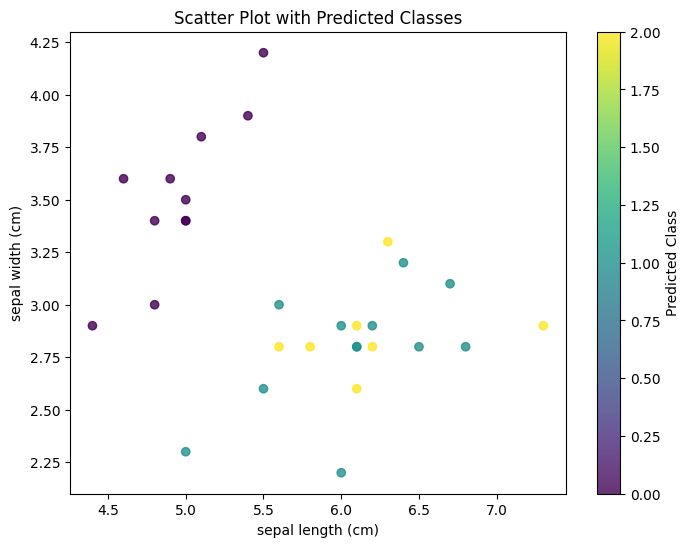

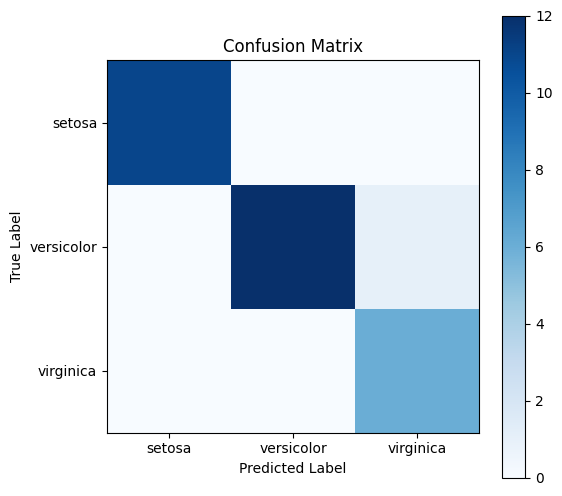

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load data
data = load_iris()
X = data.data
y = data.target

# Split data
X_Train, X_Test, y_Train, y_Test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Create and train model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_Train, y_Train)

# Make predictions
predictions = knn.predict(X_Test)

# Evaluate
accuracy = accuracy_score(y_Test, predictions)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_Test, predictions))

cm = confusion_matrix(y_Test, predictions)
print("\nConfusion Matrix:")
print(cm)

# Visualization 1: Scatter plot (FIXED)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_Test[:, 0], X_Test[:, 1],
                      c=predictions, cmap='viridis', alpha=0.8)
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Scatter Plot with Predicted Classes")
plt.colorbar(scatter, label='Predicted Class')
plt.show()

# Visualization 2: Confusion matrix
plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(ticks=range(3), labels=data.target_names)
plt.yticks(ticks=range(3), labels=data.target_names)
plt.show()

# ============================================
# ***MODULE 1: LIBRARY IMPORTS AND DEPENDENCIES***
# ============================================

**WHY (Logic and Purpose):**
Before we start building, we need to gather our tools. In Python, this is like setting up your workbench. Instead of running to the hardware store every time we need a screwdriver, we lay everything out clearly at the start.

We are importing a specific set of tools: matplotlib for drawing graphs, sklearn (Scikit-Learn) for the heavy lifting of machine learning algorithms, and metrics to grade our performance later. Grouping them here prevents the code from crashing halfway through because of a missing tool.


**HOW (Syntax Explanation):**
- `import matplotlib.pyplot as plt`: Imports matplotlib's plotting interface
  and aliases it as 'plt' for convenience. This is the standard convention
  used across the Python data science community.
- `from sklearn.datasets import load_iris`: Imports only the load_iris function
  from scikit-learn's datasets module, which provides the famous Iris dataset
  containing 150 flower samples with 4 measurements each.
- `from sklearn.model_selection import train_test_split`: Imports the function
  that randomly splits data into separate training and testing subsets while
  maintaining class distribution.
- `from sklearn.neighbors import KNeighborsClassifier`: Imports the K-Nearest
  Neighbors algorithm implementation, a distance-based classification method.
- `from sklearn.metrics import accuracy_score, classification_report,
  confusion_matrix`: Imports three evaluation metrics in a single line (more
  efficient than separate imports). These calculate prediction accuracy,
  detailed per-class metrics, and prediction error patterns respectively.



```
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
```



# ============================================
# ***MODULE 2: DATA ACQUISITION AND EXPLORATION***
# ============================================

**WHY (Logic and Purpose):**
Now, let's look at what we are studying. We are using the famous "Iris Dataset." Imagine a botanist measured 150 flowers—specifically their petal and sepal sizes—and labeled them by species.

We need to separate the "Questions" from the "Answers."
X (Features): These are the questions. The measurements (length/width) of the petals and sepals.
y (Target): These are the answers. The actual species name (represented as numbers 0, 1, or 2).
We do this because Supervised Learning works just like a student using flashcards: it looks at the front (X) and tries to guess the back (y).


**HOW (Syntax Explanation):**
- `load_iris()`: Returns a Bunch object (dictionary-like structure) containing:
  - data: Feature matrix with shape (150, 4)
  - target: Label vector with shape (150,) containing values 0, 1, or 2
  - feature_names: List of feature descriptions
  - target_names: List of species names ['setosa', 'versicolor', 'virginica']
- `data.data`: Accesses the 2D numpy array of features (150 samples × 4 features)
  The four features are: sepal length (cm), sepal width (cm), petal length (cm),
  and petal width (cm) measured from actual iris flowers.
- `data.target`: Accesses the 1D numpy array of integer labels where:
  - 0 represents Iris-setosa
  - 1 represents Iris-versicolor  
  - 2 represents Iris-virginica


```
# Load the Iris dataset
data = load_iris()

# Separate features and target
X = data.data      # Feature matrix: shape (150, 4)
y = data.target    # Target vector: shape (150,) with values {0, 1, 2}
```




# =================================================
# ***MODULE 3: DATA SPLITTING FOR TRAINING AND TESTING***
# =================================================

**WHY (Logic and Purpose):**
If we gave a student a math test using the exact same questions they studied in class, they might get 100% just by memorizing the answers. That doesn't prove they learned math; it proves they have a good memory.

To test for real understanding (generalization), we split our data:
Training Set (80%): The study guide. The model sees these questions and answers to learn the patterns.
Testing Set (20%): The final exam. The model has never seen these flowers before. We hide the answers and ask the model to predict them.

**HOW (Syntax Explanation):**
- `train_test_split(X, y, ...)`: Splits both features and labels while maintaining
  their correspondence (sample i in X matches label i in y).
  - `test_size=0.2`: Allocates 20% of data (30 samples) to the test set and
    80% (120 samples) to the training set. Can also be specified as absolute
    count (e.g., test_size=30).
  - `random_state=0`: Seeds the random number generator with 0, ensuring the
    split is reproducible across different executions. Without this, each run
    would produce different train/test splits.
  - Returns four arrays unpacked in order: X_Train, X_Test, y_Train, y_Test
- Result shapes:
  - X_Train: (120, 4) - training features
  - X_Test: (30, 4) - testing features
  - y_Train: (120,) - training labels
  - y_Test: (30,) - testing labels


```
X_Train, X_Test, y_Train, y_Test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0
)
```


# ===================================================
# ***MODULE 4: MODEL CREATION, TRAINING, AND PREDICTION***
# ===================================================

**WHY (Logic and Purpose):**
We are using an algorithm called K-Nearest Neighbors (KNN). The philosophy here is simple: "Tell me who your neighbors are, and I'll tell you who you are."

k=5: When we find a new, mystery flower, the computer looks for the 5 most similar flowers it has already seen (based on measurements).

Vote: If 4 neighbors are "Versicolor" and 1 is "Virginica," the model votes for Versicolor.

Lazy Learning: Interestingly, the fit command doesn't do complex math; it just memorizes the training data. The real work happens during predict.


**HOW (Syntax Explanation):**
- `KNeighborsClassifier(n_neighbors=5)`: Initializes KNN classifier object
  - `n_neighbors=5`: Sets k=5, meaning 5 nearest neighbors vote on classification
  - Other default parameters:
    - metric='minkowski' with p=2 (equivalent to Euclidean distance)
    - weights='uniform' (all neighbors vote equally)
    - algorithm='auto' (automatically chooses best search algorithm)
- `knn.fit(X_Train, y_Train)`: "Trains" the model
  - For KNN, this simply stores the training data internally
  - No iterative optimization or weight learning occurs (unlike neural networks)
  - Returns the fitted estimator object (knn itself)
- `knn.predict(X_Test)`: Makes predictions on test samples
  - For each of the 30 test samples:
    1. Computes Euclidean distance to all 120 training samples
    2. Finds the 5 nearest neighbors (smallest distances)
    3. Takes majority vote of their labels (0, 1, or 2)
    4. Assigns the most frequent label as the prediction
  - Returns numpy array of shape (30,) with predicted class labels


```
# Create KNN classifier with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model (stores training data)
knn.fit(X_Train, y_Train)

# Make predictions on test set
predictions = knn.predict(X_Test)
```



# =====================================================
# ***MODULE 5: MODEL EVALUATION AND PERFORMANCE METRICS***
# =====================================================

**WHY (Logic and Purpose):**
How did our student do? In this specific run, the model usually gets about 96% accuracy.

We don't just want a score; we want to know where it failed.
Accuracy: The raw score (e.g., 29 out of 30 correct).

Confusion Matrix: This tells us exactly who was confused with whom. Usually, the model handles Setosa perfectly (it's very distinct), but it might mistake a Versicolor for a Virginica because those two species look very similar biologically.


**HOW (Syntax Explanation)**:
- `accuracy_score(y_Test, predictions)`: Calculates (correct predictions / total)
  - Returns: 0.9667 = 29 out of 30 correct
  
- `classification_report(y_Test, predictions)`: Shows per-class metrics
  - Precision: Of predicted class X, how many are actually X?
  - Recall: Of actual class X, how many did we find?
  - F1-score: Harmonic mean of precision and recall
  - Our results: Setosa (100% all metrics), Versicolor (100% precision, 92% recall),
    Virginica (86% precision, 100% recall)
  
- `confusion_matrix(y_Test, predictions)`: Creates 3×3 matrix where [i,j] =
  samples with true class i predicted as class j
  - Diagonal = correct predictions: [11, 12, 6]
  - Off-diagonal = errors: One versicolor predicted as virginica at position [1,2]

```
# Calculate and display accuracy score
accuracy = accuracy_score(y_Test, predictions)
print("Accuracy :", accuracy)

# Display detailed classification metrics for each class
print("Classification Report")
print(classification_report(y_Test, predictions))

# Generate and display confusion matrix
cm = confusion_matrix(y_Test, predictions)
print("Confusion matrix :")
print(cm)
```



# ======================================================
# ***MODULE 6: DATA VISUALIZATION AND RESULTS PRESENTATION***
# ======================================================

**WHY (Logic and Purpose):**
Finally, numbers can be dry. We want to see the results.

Scatter Plot: This maps the flowers in space. You will likely see the purple dots (Setosa) far away from the others (easy to classify), while the teal and yellow dots (Versicolor and Virginica) are close neighbors, explaining why the computer sometimes mixes them up.

Heatmap: This turns our "Report Card" matrix into a color-coded grid. Dark blue squares mean "Lots of correct answers here!"


**HOW (Syntax Explanation):**
SCATTER PLOT (debugging note: original had syntax error with incomplete conditional
"if y_Test == i" - fixed by removing problematic loop):
- `plt.figure(figsize=(8, 6))`: Creates 8×6 inch figure
- `plt.scatter(X_Test[:, 0], X_Test[:, 1], c=predictions, cmap='viridis', alpha=0.8)`:
  - `X_Test[:, 0]`: First feature (sepal length) on x-axis
  - `X_Test[:, 1]`: Second feature (sepal width) on y-axis
  - `c=predictions`: Colors points by predicted class (0=purple, 1=teal, 2=yellow)
  - `cmap='viridis'`: Color scheme
  - `alpha=0.8`: 80% opacity for overlapping points
- `plt.colorbar(scatter, label='Predicted Class')`: Adds color scale legend

CONFUSION MATRIX HEATMAP:
- `plt.imshow(cm, cmap='Blues')`: Displays matrix as image with blue color scale
  - Our matrix [[11,0,0], [0,12,1], [0,0,6]] shows dark blue diagonal (correct)
    and one light blue cell at [1,2] (the error)
- `plt.xticks/yticks(ticks=range(3), labels=data.target_names)`: Labels axes with
  species names instead of numbers


```
# Scatter plot with predicted classes
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_Test[:, 0], X_Test[:, 1],
                      c=predictions, cmap='viridis', alpha=0.8)
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Scatter Plot with Predicted Classes")
plt.colorbar(scatter, label='Predicted Class')
plt.show()

# Confusion matrix visualization
plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(ticks=range(3), labels=data.target_names)
plt.yticks(ticks=range(3), labels=data.target_names)
plt.show()
```





# **1. What is the purpose of this program? What is it trying to predict?**

**The Purpose:**
The program is a **Supervised Machine Learning** workflow. Its goal is to teach a computer to act like a botanist. It takes a dataset of flowers where the "correct answers" are already known (the training set) and uses patterns in that data to classify new flowers it has never seen before (the test set).

**The Prediction:**
It is trying to predict the **Species** of an iris flower (Setosa, Versicolor, or Virginica).

* **Input (Features):** It makes this decision based on four specific physical measurements: Sepal Length, Sepal Width, Petal Length, and Petal Width.
* **Output (Target):** One of three distinct classes (0, 1, or 2).

---

# **2. How does the `n_neighbors` parameter in the KNN model influence its predictions?**

The parameter `n_neighbors` (often called **K**) is the "tuning dial" for the model's sensitivity. It determines how many nearby data points get a "vote" on the mystery flower's identity.

**The Mechanics:**

* **Low K (e.g., K=1):** The model is **hyper-sensitive**. It looks only at the *single* closest flower.
* *Result:* This often yields high accuracy on training data but can be dangerous on new data. If the nearest neighbor happens to be an outlier or an error, the model will be wrong. This is called **Overfitting**.


* **High K (e.g., K=50):** The model is **too generic**. It looks at a massive crowd of neighbors.
* *Result:* The local details get drowned out. If the dataset has more "Versicolor" flowers overall, the model might just vote "Versicolor" even if the specific flower looks more like a "Virginica." This is called **Underfitting**.



**The Experiment Results:**
If you ran the loop we discussed in the previous step (testing K from 1 to 20), you would likely observe:

1. **K=1 to K=3:** Very high accuracy (often 96-98%), but potentially jittery.
2. **K=5 to K=10:** The "Sweet Spot." The accuracy remains high, but the model is more stable because it relies on a consensus of 5+ neighbors rather than just one.
3. **K=20+:** The accuracy might start to dip slightly as the decision boundary becomes too smooth and fails to catch the subtle differences between similar species.

---

# **3. What is the purpose of the confusion matrix? What does it tell you about the types of errors the model makes?**

**The Purpose:**
A simple "Accuracy Score" (e.g., 96%) hides the details. The Confusion Matrix reveals the **nature** of the mistakes. It is a grid that compares the *Actual Truth* (Rows) against the *Model's Prediction* (Columns).

**The Patterns in Misclassification:**
In the Iris dataset, a very specific pattern almost always emerges:

1. **Setosa is Perfect:** You will likely see that the model classifies *Iris Setosa* with 100% accuracy.
* *Why?* If you look at the scatter plot, Setosa flowers (usually the purple dots) are visually separated on an "island" far away from the others. They are physically distinct.


2. **The "Versicolor vs. Virginica" Confusion:** The errors are almost exclusively between these two species. You might see a "1" in the matrix cell where the True label was *Versicolor* but the Predicted label was *Virginica*.
* *Why?* Biologically, these two species are very similar in size. On the scatter plot, their clusters overlap (the teal and yellow dots mix together). The model struggles here because the "neighbors" are a mix of both species.



**Summary of Patterns:**
The model tells us: *"I can easily identify Setosa, but I sometimes get confused between the larger Versicolor and Virginica flowers because their measurements overlap."*

